In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
base = 'drive/MyDrive/data/A/'
train_data = pd.read_csv(os.path.join(base, 'train_weights.csv'))

In [ ]:
train_data.head()

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9,MSE
0,0.355,0.612,0.482,-1.220,-0.412,-0.745,-1.172,-1.760,0.479,1.180,69.113
1,-0.571,0.767,0.537,-0.904,-0.114,0.042,0.739,0.110,-1.743,1.831,67.790
2,0.389,-0.994,-1.537,-0.871,-0.351,-0.679,-0.475,-1.019,0.555,-1.048,32.273
3,0.539,0.679,-1.504,-0.472,0.909,0.158,0.866,1.084,-1.127,-0.436,18.747
4,0.289,-0.284,0.330,1.462,-0.205,0.213,-0.133,-2.064,-0.846,-0.223,62.239


In [ ]:
train_data.iloc[:10, :]

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9,MSE
0,0.355,0.612,0.482,-1.220,-0.412,-0.745,-1.172,-1.760,0.479,1.180,69.113
1,-0.571,0.767,0.537,-0.904,-0.114,0.042,0.739,0.110,-1.743,1.831,67.790
2,0.389,-0.994,-1.537,-0.871,-0.351,-0.679,-0.475,-1.019,0.555,-1.048,32.273
3,0.539,0.679,-1.504,-0.472,0.909,0.158,0.866,1.084,-1.127,-0.436,18.747
4,0.289,-0.284,0.330,1.462,-0.205,0.213,-0.133,-2.064,-0.846,-0.223,62.239
5,-0.470,0.784,1.069,-0.706,1.055,-0.537,0.290,-0.408,-1.361,-0.796,65.369
6,-1.665,0.797,1.348,0.898,-0.318,0.693,-1.960,1.023,1.850,0.664,44.750
7,-0.511,0.833,0.054,-1.043,-1.361,-0.234,0.021,-2.581,2.910,-0.445,56.223
8,1.296,0.025,1.267,2.216,-0.548,-0.345,0.593,0.978,0.216,-0.165,83.636
9,-1.401,0.087,-1.030,0.002,1.212,0.384,0.348,-1.552,0.479,-0.537,31.525


In [ ]:
test_data = pd.read_csv(os.path.join(base, 'test_weights.csv'))

In [ ]:
test_data.head()

,W0,W1,W2,W3,W4,W5,W6,W7,W8,W9
0,0.370,-0.424,0.190,-1.882,2.893,-0.070,-1.191,0.521,-0.882,-1.231
1,1.162,-0.310,0.915,-0.297,-0.994,-0.500,0.202,0.508,1.848,1.147
2,1.691,1.329,-0.383,-0.852,-0.576,0.698,0.036,0.442,-0.518,-0.129
3,0.199,1.034,-0.673,1.376,-0.221,-0.256,-0.196,0.217,0.918,-1.259
4,0.005,-0.888,0.049,1.148,-1.260,-1.746,-1.398,-1.417,-0.912,-0.367


# Аналитическое решение (60 баллов)

In [ ]:
import numpy as np

def solve_x_y(W, mse, n_restarts=20, max_iter=500, tol=1e-9, random_state=42, reg=1e-8):
    rng = np.random.default_rng(random_state)
    m, d = W.shape

    r = np.sqrt(np.maximum(mse, 0.0))
    A = np.hstack([W, -np.ones((m, 1))])
    AtA = A.T @ A + reg * np.eye(d + 1)  # регуляризация для устойчивости
    best = {'loss': np.inf}

    for restart in range(n_restarts):
        s = rng.choice([-1.0, 1.0], size=m)
        prev_s = None
        prev_loss = np.inf

        for it in range(max_iter):
            b = -s * r
            rhs = A.T @ b
            sol = np.linalg.solve(AtA, rhs)
            x, y = sol[:d], sol[d]

            resid = y - W @ x
            new_s = np.sign(resid)
            new_s[new_s == 0] = 1.0

            pred = resid**2
            loss = np.sum((pred - mse)**2)

            if abs(loss - prev_loss) < tol:
                break
            prev_loss = loss

            if prev_s is not None and np.array_equal(new_s, prev_s):
                break
            prev_s = new_s
            s = new_s

        if loss < best['loss']:
            best = {'x': x, 'y': float(y), 's': s.copy(), 'loss': float(loss), 'pred': pred}

    return best

In [ ]:
W, mse = train_data.iloc[:, :-1].to_numpy(), train_data.iloc[:, -1].to_numpy()

In [ ]:
best = solve_x_y(W, mse)

In [ ]:
best['x']

array([-0.46986856, -0.00335025, -0.8819288 , -0.04929558,  0.17508168,
        0.35373629, -0.05582945,  0.37068844,  0.23837776, -0.17262631])

In [ ]:
best['y']

6.97425410198438

In [ ]:
best['loss']

156366.27251934336

In [ ]:
import json

answers = []
for _, row in test_data.iterrows():
    w = row.to_numpy()
    mse = float(np.mean((best['y'] - best['x'].dot(w)) ** 2))
    entry = {f"W{i}": float(w[i]) for i in range(len(w))}
    entry["MSE"] = mse
    answers.append(entry)

with open("answers.json", "w") as f:
    json.dump(answers, f, indent=4)


# KNeighborsRegressor (72 балла)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
X, y = train_data.drop('MSE', axis=1).copy().to_numpy(), train_data['MSE'].copy().to_numpy()

(array([ 76., 221., 249., 208., 126.,  55.,  41.,  16.,   5.,   3.]),
 array([ 10.219 ,  23.3125,  36.406 ,  49.4995,  62.593 ,  75.6865,
         88.78  , 101.8735, 114.967 , 128.0605, 141.154 ]),
 <BarContainer object of 10 artists>)

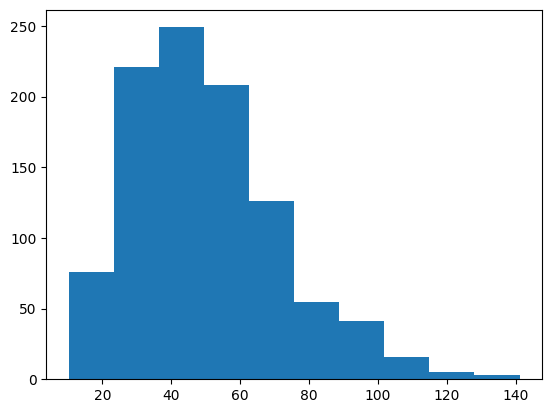

In [ ]:
plt.hist(y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
)

In [ ]:
model = KNeighborsRegressor(2,
                            weights='distance',
                            algorithm='brute',
                            p=2,
                            metric='minkowski')
model.fit(X_train, y_train)

KNeighborsRegressor(algorithm='brute', n_neighbors=2, weights='distance')

In [ ]:
y_pred = model.predict(X_val)

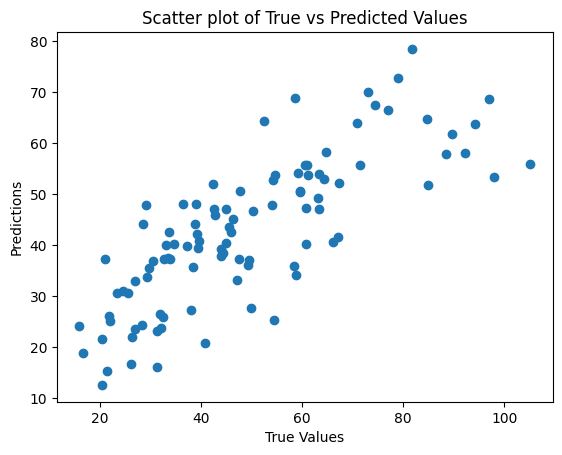

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_val, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Scatter plot of True vs Predicted Values')
plt.show()

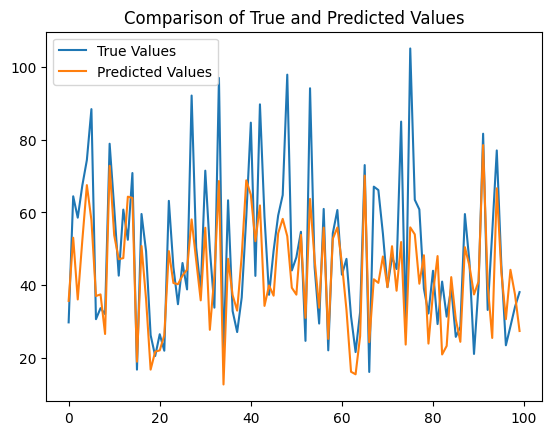

In [ ]:
plt.plot(y_val, label='True Values')
plt.plot(y_pred, label='Predicted Values')
plt.legend()
plt.title("Comparison of True and Predicted Values")
plt.show()

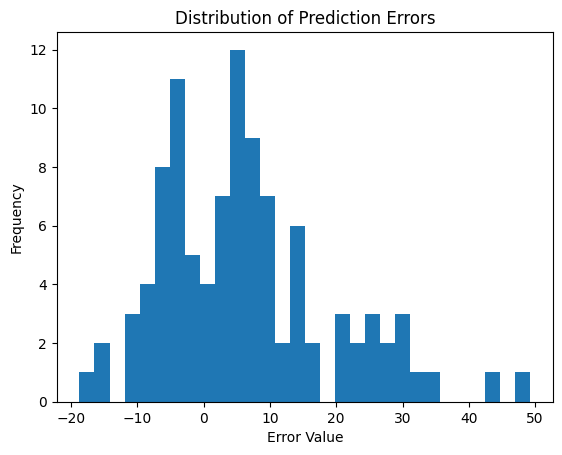

In [ ]:
errors = y_val - y_pred
plt.hist(errors, bins=30)
plt.xlabel('Error Value')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_log_error

In [ ]:
rmsle = root_mean_squared_log_error(y_pred, y_val)

In [ ]:
rmsle

0.2859752916946843

In [ ]:
model = KNeighborsRegressor(5,
                            weights='distance',
                            algorithm='brute',
                            p=2,
                            metric='minkowski')
model.fit(X, np.exp(y))

KNeighborsRegressor(algorithm='brute', weights='distance')

(array([ 2.,  9., 21., 18., 22., 15.,  4.,  6.,  1.,  2.]),
 array([16.75006439, 23.88403662, 31.01800885, 38.15198108, 45.2859533 ,
        52.41992553, 59.55389776, 66.68786999, 73.82184222, 80.95581445,
        88.08978667]),
 <BarContainer object of 10 artists>)

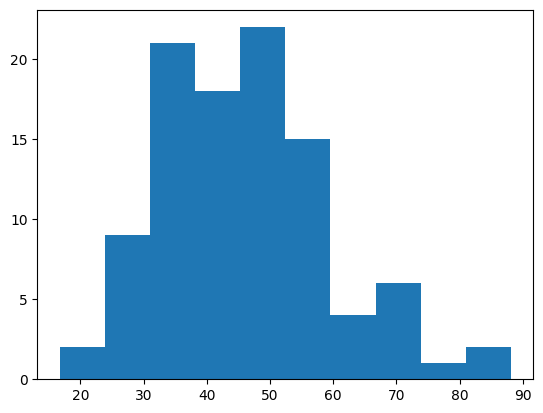

In [ ]:
import json
X_test = test_data.to_numpy()
answers = []

test_mse = model.predict(X_test)
plt.hist(test_mse)
# for index, row in test_data.iterrows():
#     w = row.to_numpy()
#     mse = float(test_mse[index])
#     entry = {f"W{i}": float(w[i]) for i in range(len(w))}
#     entry["MSE"] = mse
#     answers.append(entry)

# with open("answers.json", "w") as f:
#     json.dump(answers, f, indent=4)


# KNeighborsRegressor log target (72 балла)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
X, y = train_data.drop('MSE', axis=1).copy().to_numpy(), train_data['MSE'].copy().to_numpy()
y = np.log(y)

(array([  4.,  22.,  43.,  85., 175., 214., 236., 138.,  70.,  13.]),
 array([2.32424873, 2.58680901, 2.84936928, 3.11192956, 3.37448984,
        3.63705011, 3.89961039, 4.16217066, 4.42473094, 4.68729122,
        4.94985149]),
 <BarContainer object of 10 artists>)

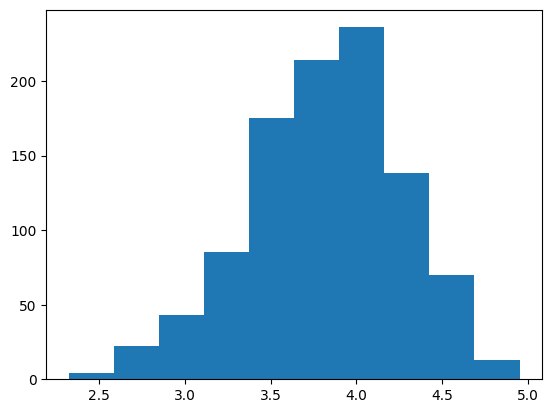

In [ ]:
plt.hist(y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
)

In [ ]:
model = KNeighborsRegressor(5,
                            weights='distance',
                            algorithm='brute',
                            p=2,
                            metric='minkowski')
model.fit(X_train, y_train)

KNeighborsRegressor(algorithm='brute', weights='distance')

In [ ]:
y_pred = model.predict(X_val)

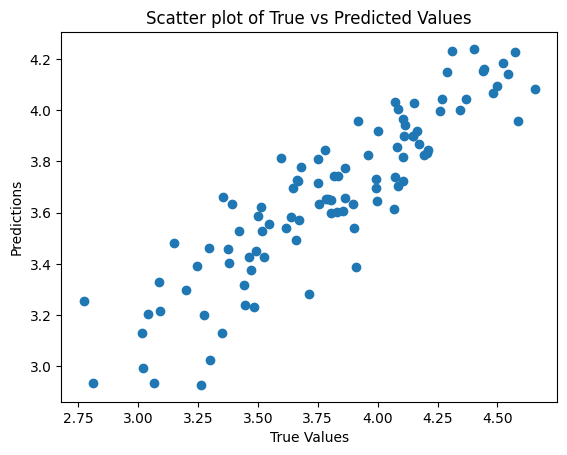

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_val, y_pred)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Scatter plot of True vs Predicted Values')
plt.show()

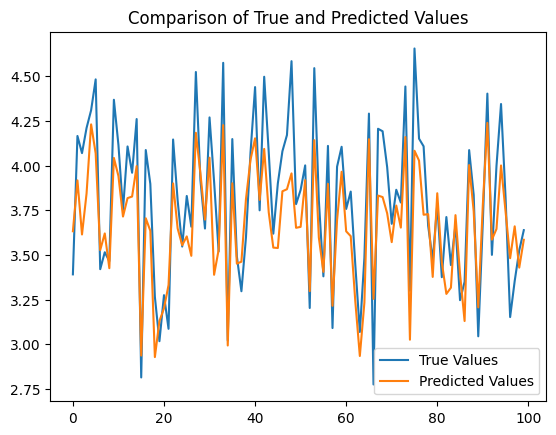

In [ ]:
plt.plot(y_val, label='True Values')
plt.plot(y_pred, label='Predicted Values')
plt.legend()
plt.title("Comparison of True and Predicted Values")
plt.show()

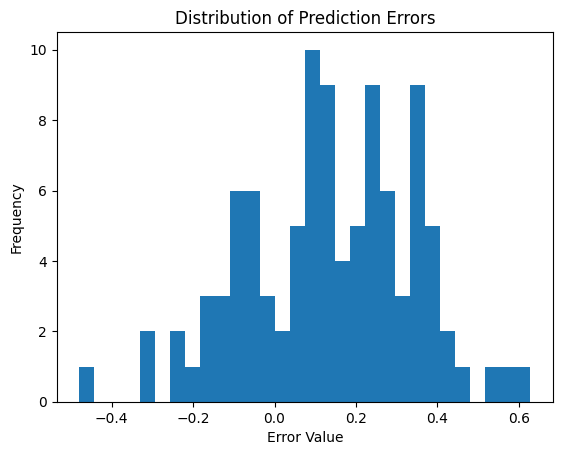

In [ ]:
errors = y_val - y_pred
plt.hist(errors, bins=30)
plt.xlabel('Error Value')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
rmse = root_mean_squared_error(y_pred, y_val)

In [ ]:
rmsle

0.22650355983694148

In [ ]:
model = KNeighborsRegressor(5,
                            weights='distance',
                            algorithm='brute',
                            p=2,
                            metric='minkowski')
model.fit(X, y)

KNeighborsRegressor(algorithm='brute', weights='distance')

In [ ]:
import json
X_test = test_data.to_numpy()
answers = []

test_mse = model.predict(X_test)
for index, row in test_data.iterrows():
    w = row.to_numpy()
    mse = float(test_mse[index])
    entry = {f"W{i}": float(w[i]) for i in range(len(w))}
    entry["MSE"] = mse
    answers.append(entry)

with open("answers.json", "w") as f:
    json.dump(answers, f, indent=4)


# Ridge + log target (56 баллов)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
import numpy as np

# Расширенная сетка гиперпараметров
param_grid = {
    'alpha': [10.0],  # Регуляризационный параметр
    'fit_intercept': [True, False],  # Включать ли свободный член
    'tol': [1e-5],  # Точность решения
    'max_iter': [10, 25, 50, 75, 100],  # Максимальное количество итераций
    'solver': ['auto'],
}

# Создание модели
ridge = Ridge(random_state=42)

# Поиск лучших гиперпараметров
grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Использовать все доступные ядра
    verbose=1
)

grid_search.fit(X_train, y_train)

# Лучшая модель
best_ridge = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best MSE: {-grid_search.best_score_:.6f}")
print(f"Best RMSE: {np.sqrt(-grid_search.best_score_):.6f}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters: {'alpha': 10.0, 'fit_intercept': True, 'max_iter': 10, 'solver': 'auto', 'tol': 1e-05}
Best MSE: 0.077095
Best RMSE: 0.277660


In [ ]:
ridge = Ridge(**grid_search.best_params_, random_state=42)

In [ ]:
ridge

Ridge(alpha=10.0, max_iter=10, random_state=42, tol=1e-05)

In [ ]:
ridge.fit(X_train, y_train)

Ridge(alpha=10.0, max_iter=10, random_state=42, tol=1e-05)

In [ ]:
y_pred = ridge.predict(X_val)

In [ ]:
rmse = root_mean_squared_error(y_pred, y_val)

In [ ]:
rmse

0.2770168940146695

In [ ]:
ridge = Ridge(**grid_search.best_params_, random_state=42)
ridge.fit(X, y)

Ridge(alpha=10.0, max_iter=10, random_state=42, tol=1e-05)

In [ ]:
import json
X_test = test_data.to_numpy()
answers = []

test_mse = np.exp(ridge.predict(X_test))
for index, row in test_data.iterrows():
    w = row.to_numpy()
    mse = float(test_mse[index])
    entry = {f"W{i}": float(w[i]) for i in range(len(w))}
    entry["MSE"] = mse
    answers.append(entry)

with open("answers.json", "w") as f:
    json.dump(answers, f, indent=4)


(array([24., 33., 21., 17.,  1.,  2.,  1.,  0.,  0.,  1.]),
 array([ 25.14825343,  37.6696614 ,  50.19106937,  62.71247734,
         75.23388531,  87.75529328, 100.27670125, 112.79810923,
        125.3195172 , 137.84092517, 150.36233314]),
 <BarContainer object of 10 artists>)

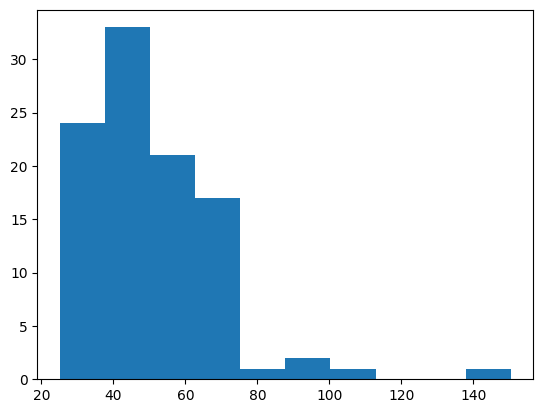

In [ ]:
plt.hist(test_mse)

# Идея с feature engineeering (100 баллов)

предположим, что y = 0 и вычислим на основе этого предположения вектор x для каждого w, записав это в таблицу
точного X конечно же мы не узнаем, но мы можем предположить решение, показав модели зависимость целевой переменной от признаков

но ясно, что эти признаки (X) будут неверными для тестовой выборки, потому что там mse неизвестно и придется подставлять какую-то статистику для этого дела.
Это не нужно.
Я думаю стоит сделать следующий пайплайн:
1) обучить KNN и добавить новую колонку - knn_mse и в train и в test
2) сделать этот feature engineering, но для knn_mse, чтобы признаки X были примерно одинакового уровня неточности (хотя все равно knn_mse на трейне будет лучше, чем на тесте)
3) Обучить какую-то модель

## 1

In [ ]:
from sklearn.neighbors import NearestNeighbors


X_train, y_train = train_data.drop('MSE', axis=1).to_numpy(), train_data['MSE'].to_numpy()
X_test = test_data.to_numpy()
knn = NearestNeighbors(n_neighbors=5, algorithm='brute').fit(X_train)

distances, indices = knn.kneighbors(X_train)
nearest_indices = indices[:, 1:]
y_train_knn = np.mean(y_train[nearest_indices], axis=1)

distances, indices = knn.kneighbors(X_test)
y_test_knn = np.mean(y_train[indices], axis=1)

##2

In [ ]:
X, y = train_data.drop(columns=['MSE']).to_numpy(), train_data['MSE'].to_numpy()
X_test = test_data.to_numpy()

In [ ]:
def build_dataset_vectorized(W, knn_mse):

    sum_w2 = np.sum(W**2, axis=1, keepdims=True)
    sqrt_mse = np.sqrt(knn_mse).reshape(-1, 1)
    X = W * sqrt_mse / sum_w2

    features = np.concatenate([X, W], axis=1)
    return features

X = build_dataset_vectorized(X, y_train_knn)
X_test = build_dataset_vectorized(X_test, y_test_knn)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


## 2.5 тестируем

In [ ]:
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor, Pool, cv
import numpy as np

def test(X, y):
    # Масштабирование
    scaler = StandardScaler()
    X_train, X_test, y_train, y_test = train_test_split(X, np.log(y), test_size=0.1, random_state=42)
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Сет гиперпараметров для быстрого поиска
    param_grid = {
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'l2_leaf_reg': [1, 3, 5],
        'iterations': [500, 1000]
    }

    best_score = float('inf')
    best_params = None

    train_pool = Pool(X_train, y_train)

    # Поиск лучших гиперпараметров через встроенный CV
    for depth in param_grid['depth']:
        for lr in param_grid['learning_rate']:
            for l2 in param_grid['l2_leaf_reg']:
                for iters in param_grid['iterations']:
                    params = {
                        'depth': depth,
                        'learning_rate': lr,
                        'l2_leaf_reg': l2,
                        'iterations': iters,
                        'loss_function': 'RMSE',
                        'task_type': 'GPU',
                        'verbose': 200,
                        'random_seed': 42
                    }
                    cv_results = cv(
                        params=params,
                        pool=train_pool,
                        fold_count=5,
                        early_stopping_rounds=50,
                        plot=False
                    )

                    mean_rmse = np.min(cv_results['test-RMSE-mean'])
                    print(f'depth={depth}, lr={lr}, l2={l2}, iters={iters}, CV RMSE={mean_rmse:.5f}')

                    if mean_rmse < best_score:
                        best_score = mean_rmse
                        best_params = params.copy()

    print("Лучшие гиперпараметры:", best_params, "с CV RMSE:", best_score)

    # Финальное обучение на всей выборке
    final_model = CatBoostRegressor(**best_params)
    final_model.fit(X_train, y_train)

    y_pred = final_model.predict(X_test)
    test_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    print(f"Test RMSE на логах: {test_rmse:.5f}")

    return best_params, best_score


In [ ]:
best_params, best_score = test(X, y)


Training on fold [0/5]
0:	learn: 3.8093748	test: 3.8354918	best: 3.8354918 (0)	total: 35.7ms	remaining: 17.8s
200:	learn: 0.6033178	test: 0.5986329	best: 0.5986329 (200)	total: 6.93s	remaining: 10.3s
400:	learn: 0.2356755	test: 0.2336619	best: 0.2336619 (400)	total: 8.12s	remaining: 2s
499:	learn: 0.2022124	test: 0.2028623	best: 0.2028623 (499)	total: 8.69s	remaining: 0us
bestTest = 0.2028622615
bestIteration = 499
Training on fold [1/5]
0:	learn: 3.8192414	test: 3.7964299	best: 3.7964299 (0)	total: 9.12ms	remaining: 4.55s
200:	learn: 0.6023362	test: 0.6084337	best: 0.6084337 (200)	total: 1.13s	remaining: 1.68s
400:	learn: 0.2296625	test: 0.2511809	best: 0.2511809 (400)	total: 2.32s	remaining: 572ms
499:	learn: 0.1959970	test: 0.2207238	best: 0.2207238 (499)	total: 2.88s	remaining: 0us
bestTest = 0.2207238052
bestIteration = 499
Training on fold [2/5]
0:	learn: 3.8093591	test: 3.8361272	best: 3.8361272 (0)	total: 6.49ms	remaining: 3.24s
200:	learn: 0.5995134	test: 0.6369335	best: 0.636

##3

In [ ]:
best_params

{'depth': 4,
 'learning_rate': 0.1,
 'l2_leaf_reg': 1,
 'iterations': 1000,
 'loss_function': 'RMSE',
 'task_type': 'GPU',
 'verbose': 200,
 'random_seed': 42}

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X, y = train_data.drop(columns=['MSE']).to_numpy(), train_data['MSE'].to_numpy()
X_test = test_data.to_numpy()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

final_model = CatBoostRegressor(**best_params)
final_model.fit(X, np.log(y))
y_pred = np.exp(final_model.predict(X_test))

import json

answers = []
for i, row in test_data.iterrows():
    w = row.to_numpy()
    mse = float(y_pred[i])
    entry = {f"W{j}": float(w[j]) for j in range(len(w))}
    entry["MSE"] = mse
    answers.append(entry)

with open("answers.json", "w") as f:
    json.dump(answers, f, indent=4)

0:	learn: 0.4219312	total: 42.5ms	remaining: 42.5s
200:	learn: 0.1195393	total: 3.19s	remaining: 12.7s
400:	learn: 0.0929445	total: 6.54s	remaining: 9.77s
600:	learn: 0.0820247	total: 8.03s	remaining: 5.33s
800:	learn: 0.0724632	total: 9.04s	remaining: 2.25s
999:	learn: 0.0669906	total: 10s	remaining: 0us


(array([ 7., 17., 23., 22., 11.,  9.,  5.,  3.,  1.,  2.]),
 array([ 16.28987378,  26.74363424,  37.1973947 ,  47.65115516,
         58.10491563,  68.55867609,  79.01243655,  89.46619701,
         99.91995747, 110.37371793, 120.82747839]),
 <BarContainer object of 10 artists>)

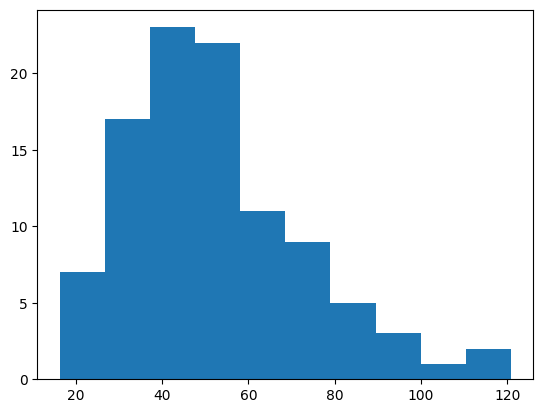

In [ ]:
import matplotlib.pyplot as plt
plt.hist(y_pred)